In [1]:
# ============================================================
# Cell Imports (Cleaned and Deduplicated)
# ============================================================

# Built-in modules
import os
import random
import time

# Data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# PyTorch Data & Vision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize

# Utilities and Extras
import gradio as gr
from tabulate import tabulate
from torchinfo import summary  
from tqdm.notebook import tqdm

# ============================================================
# Setup
# ============================================================
%matplotlib inline
print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


In [2]:
!rm -rf /kaggle/working/*

In [3]:
# ============================================================
# Cell Configuration
# ============================================================

SEED = 42

DATA_ROOT = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

IMG_SIZE = 48
BATCH_SIZE = 32
NUM_CLASSES = 7

NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Dataset:", DATA_ROOT)

Device: cuda
Dataset: /kaggle/input/datasets/shawon10/ckplus/CK+48


In [4]:
# ============================================================
# Cell Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [5]:
# ============================================================
# Cell Check Dataset
# ============================================================

assert os.path.exists(DATA_ROOT), f"Dataset not found: {DATA_ROOT}"

class_names = sorted([
    folder for folder in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, folder))
])

print("Classes:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

print("\nNumber of classes:", len(class_names))

Classes:
0: anger
1: contempt
2: disgust
3: fear
4: happy
5: sadness
6: surprise

Number of classes: 7


In [6]:
# ============================================================
# Cell  Dataset Statistics
# ============================================================

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(DATA_ROOT, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    class_counts[class_name] = len(images)

counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Emotion", "Images"]
)

counts_df

,Emotion,Images
0,anger,135
1,contempt,54
2,disgust,177
3,fear,75
4,happy,207
5,sadness,84
6,surprise,249


In [7]:
# ============================================================
# Cell Total Dataset Size
# ============================================================

total_images = counts_df["Images"].sum()

print("Total images:", total_images)
print("Number of classes:", len(class_names))

Total images: 981
Number of classes: 7


/tmp/ipykernel_3274/3428330812.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df,x="Emotion",y="Images",palette="Set1")


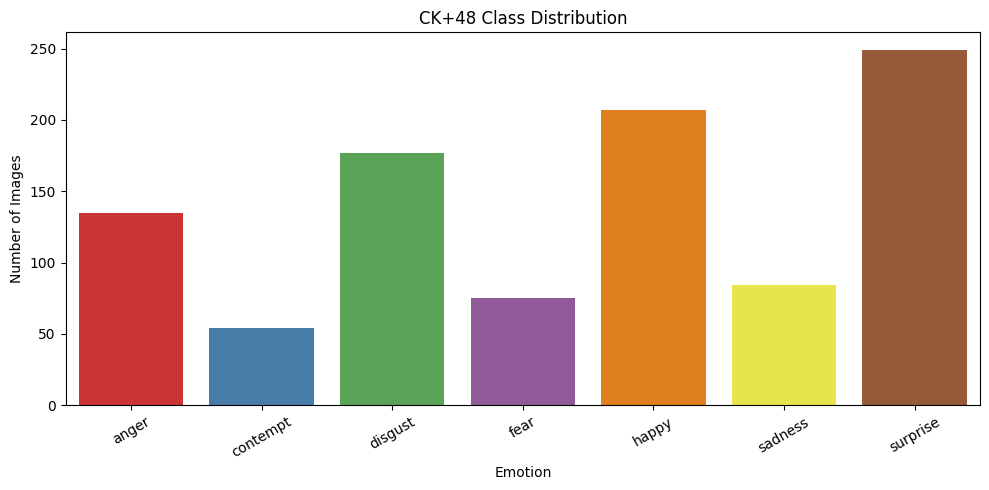

In [8]:
# ============================================================
# Cell Class Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(data=counts_df,x="Emotion",y="Images",palette="Set1")

plt.title("CK+48 Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

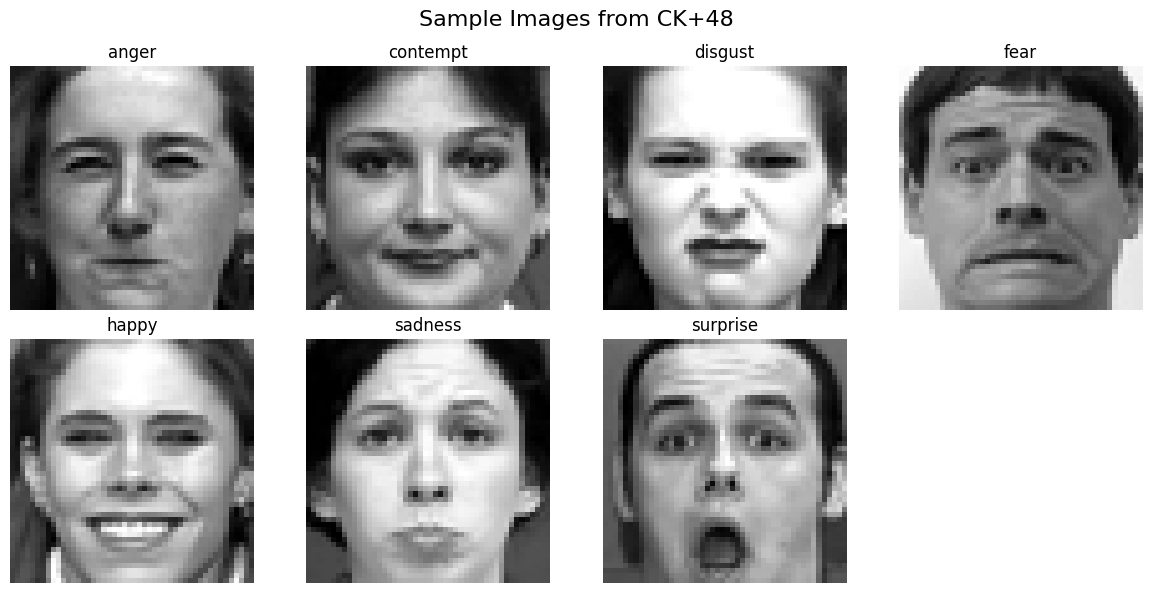

In [9]:
# ============================================================
# Cell Sample Images
# ============================================================

fig, axes = plt.subplots(2, 4,figsize=(12, 6))

for ax, class_name in zip(axes.flat, class_names):
    
    class_path = os.path.join(DATA_ROOT, class_name)
    
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    
    image_path = os.path.join(
        class_path,
        random.choice(image_files)
    )
    
    image = Image.open(image_path).convert("L")
    
    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

# Hide unused subplot
axes.flat[-1].axis("off")

plt.suptitle("Sample Images from CK+48", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cell Train / Validation / Test Split
# ============================================================

full_dataset = datasets.ImageFolder(
    root=DATA_ROOT
)

print("Total samples:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total samples: 981
Classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
Class mapping: {'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'sadness': 5, 'surprise': 6}


In [11]:
# ============================================================
# Cell Image Transformations
# ============================================================

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

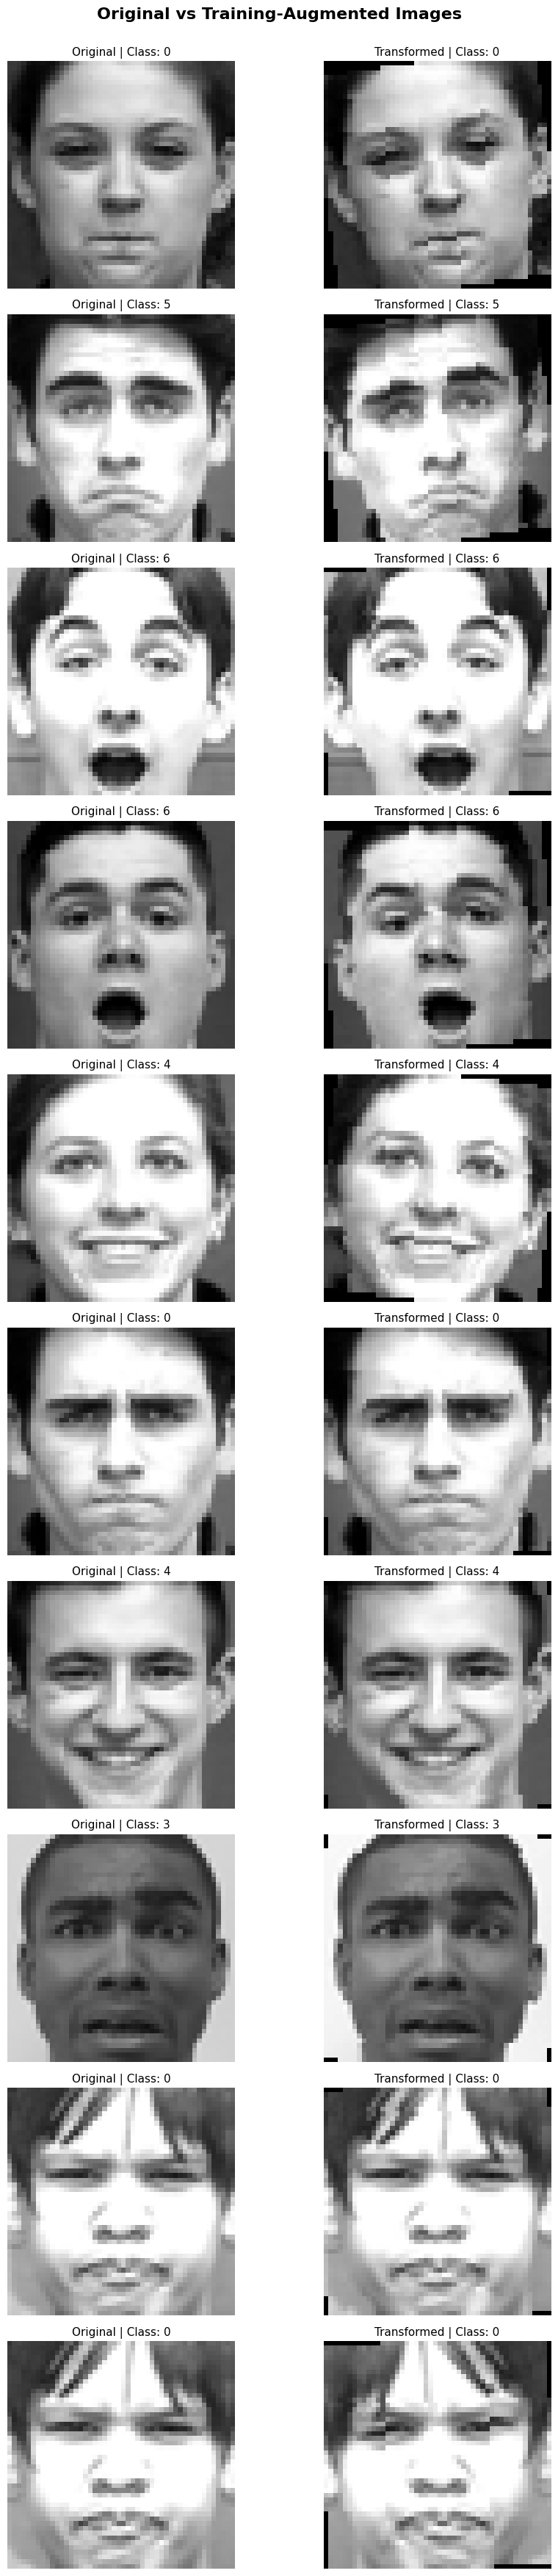

In [12]:
# ============================================================
# Visualize Original vs Transformed Images
# Directly from Raw Dataset
# ============================================================


def visualize_from_raw_dataset(
    dataset,
    transform,
    num_samples=10
):
    """
    Displays original vs transformed images side-by-side.

    Parameters
    ----------
    dataset : Dataset
        Raw dataset WITHOUT transforms attached.

    transform : torchvision.transforms.Compose
        Training transform to apply manually.

    num_samples : int
        Number of random images to visualize.
    """

    # --------------------------------------------------------
    # Validate number of samples
    # --------------------------------------------------------
    num_samples = min(num_samples, len(dataset))

    if num_samples == 0:
        raise ValueError("Dataset is empty.")

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=num_samples,
        ncols=2,
        figsize=(10, 3.5 * num_samples)
    )

    # Handle num_samples = 1
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    # --------------------------------------------------------
    # Select random indices
    # --------------------------------------------------------
    indices = random.sample(
        range(len(dataset)),
        num_samples
    )

    # --------------------------------------------------------
    # Process each image
    # --------------------------------------------------------
    for i, idx in enumerate(indices):

        # ----------------------------------------------------
        # 1. Get original image
        # ----------------------------------------------------
        orig_img, label = dataset[idx]

        # ----------------------------------------------------
        # 2. Apply training transformation
        # ----------------------------------------------------
        transformed_tensor = transform(orig_img)

        # ----------------------------------------------------
        # 3. Tensor: C,H,W -> H,W,C
        # ----------------------------------------------------
        transformed_img = (
            transformed_tensor
            .detach()
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )

        # ----------------------------------------------------
        # 4. Un-normalize
        #
        # Normalize(mean=[0.5], std=[0.5])
        #
        # Original = normalized * 0.5 + 0.5
        # ----------------------------------------------------
        transformed_img = (
            transformed_img * 0.5
        ) + 0.5

        # Keep values in valid display range
        transformed_img = np.clip(
            transformed_img,
            0,
            1
        )

        # ----------------------------------------------------
        # 5. Original image
        # ----------------------------------------------------
        axes[i, 0].imshow(
            orig_img,
            cmap="gray"
        )

        axes[i, 0].set_title(
            f"Original | Class: {label}",
            fontsize=11
        )

        axes[i, 0].axis("off")

        # ----------------------------------------------------
        # 6. Transformed image
        # ----------------------------------------------------
        axes[i, 1].imshow(
            transformed_img.squeeze(),
            cmap="gray"
        )

        axes[i, 1].set_title(
            f"Transformed | Class: {label}",
            fontsize=11
        )

        axes[i, 1].axis("off")

    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------
    fig.suptitle(
        "Original vs Training-Augmented Images",
        fontsize=16,
        fontweight="bold",
        y=1.001
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Run Visualization
# ============================================================

visualize_from_raw_dataset(
    full_dataset,
    train_transform,
    num_samples=10
)

In [13]:
# ============================================================
# Cell  Dataset Split
# ============================================================

total_size = len(full_dataset)

train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 784
Validation: 98
Test: 99


In [14]:
# ============================================================
# Cell Apply Transforms
# ============================================================

full_dataset_train = datasets.ImageFolder(
    root=DATA_ROOT,
    transform=train_transform
)

full_dataset_eval = datasets.ImageFolder(
    root=DATA_ROOT,
    transform=eval_transform
)

train_dataset, temp_dataset = random_split(
    full_dataset_train,
    [train_size, val_size + test_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset, test_dataset = random_split(
    temp_dataset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 784
Validation: 98
Test: 99


In [15]:
# ============================================================
# Cell DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 25
Validation batches: 4
Test batches: 4


In [16]:
# ============================================================
# Cell Verify Batch
# ============================================================

images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 1, 48, 48])
Label shape: torch.Size([32])
Image dtype: torch.float32
Labels: tensor([6, 6, 3, 6, 5, 4, 6, 6, 3, 6])


In [17]:
# ============================================================
# Cell Custom CNN for CK+48
# ============================================================

class CKPlusCNN(nn.Module):
    
    def __init__(self, num_classes=7):
        super(CKPlusCNN, self).__init__()

        self.features = nn.Sequential(
            
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model and send to device
NUM_CLASSES = 7  # Adjust if different
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CKPlusCNN(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Generate and print the torchinfo summary
# Note: Change (48, 48) to match your input image size if it differs (e.g., 64x64)
summary(
    model, 
    input_size=(1, 1, 48, 48),  # (Batch_Size, Channels, Height, Width)
    device=str(DEVICE)
)

Layer (type:depth-idx)                   Output Shape              Param #
CKPlusCNN                                [1, 7]                    --
├─Sequential: 1-1                        [1, 256, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 48, 48]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 48, 48]           64
│    └─ReLU: 2-3                         [1, 32, 48, 48]           --
│    └─Conv2d: 2-4                       [1, 32, 48, 48]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 48, 48]           64
│    └─ReLU: 2-6                         [1, 32, 48, 48]           --
│    └─MaxPool2d: 2-7                    [1, 32, 24, 24]           --
│    └─Dropout2d: 2-8                    [1, 32, 24, 24]           --
│    └─Conv2d: 2-9                       [1, 64, 24, 24]           18,496
│    └─BatchNorm2d: 2-10                 [1, 64, 24, 24]           128
│    └─ReLU: 2-11                        [1, 64, 24, 24]           --
│    └

In [18]:
# ============================================================
# Cell Model Parameters
# ============================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters:     616,807
Trainable Parameters: 616,807


In [19]:
# ============================================================
# Cell Forward Pass Test
# ============================================================

sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(DEVICE)

with torch.no_grad():
    outputs = model(sample_images)

print("Input shape :", sample_images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 1, 48, 48])
Output shape: torch.Size([32, 7])


In [20]:
# ============================================================
# Cell Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Loss      :", criterion)
print("Optimizer :", optimizer)
print("Scheduler :", scheduler)

Loss      : CrossEntropyLoss()
Optimizer : AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler : <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7903a18c8860>


In [21]:

# ============================================================
# Configuration
# ============================================================


EARLY_STOPPING_PATIENCE = 12

BEST_MODEL_PATH = "/kaggle/working/best_ckplus_cnn.pth"

best_val_acc = 0.0
best_val_loss = float("inf")

patience_counter = 0


# ============================================================
# Training Function
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="Train",
        leave=True,
        dynamic_ncols=True
    )

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # Statistics
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += batch_size

        current_loss = running_loss / total
        current_acc = correct / total

        pbar.set_postfix(
            loss=f"{current_loss:.4f}",
            acc=f"{current_acc * 100:.2f}%"
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# ============================================================
# Validation Function
# ============================================================

def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        loader,
        desc="Valid",
        leave=True,
        dynamic_ncols=True
    )

    with torch.no_grad():

        for images, labels in pbar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += batch_size

            current_loss = running_loss / total
            current_acc = correct / total

            pbar.set_postfix(
                loss=f"{current_loss:.4f}",
                acc=f"{current_acc * 100:.2f}%"
            )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


# ============================================================
# History
# ============================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

epoch_results = []


# ============================================================
# Main Training Loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    print()
    print("=" * 70)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 70)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_acc = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    is_best = val_acc > best_val_acc

    if is_best:

        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "class_names": class_names,
            "num_classes": NUM_CLASSES,
            "img_size": IMG_SIZE,
            "seed": SEED
        }

        torch.save(checkpoint, BEST_MODEL_PATH)
        best_marker = "YES"

    else:

        patience_counter += 1
        best_marker = "NO"

    # --------------------------------------------------------
    # Time
    # --------------------------------------------------------

    epoch_time = time.time() - start_time

    # --------------------------------------------------------
    # Store Results
    # --------------------------------------------------------

    epoch_results.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": current_lr,
        "time": epoch_time,
        "patience": patience_counter
    })

    # ========================================================
    # TABULATE RESULT
    # ========================================================

    table_data = [
        ["Epoch", f"{epoch + 1}"],
        ["Train Loss", f"{train_loss:.4f}"],
        ["Train Acc", f"{train_acc * 100:.2f}%"],
        ["Val Loss", f"{val_loss:.4f}"],
        ["Val Acc", f"{val_acc * 100:.2f}%"],
        ["Learning Rate", f"{current_lr:.2e}"],
        ["Epoch Time", f"{epoch_time:.2f}s"],
        ["Patience", f"{patience_counter}"],
        ["Best Model", f"{best_marker}"]
    ]

    print()
    print(tabulate(table_data, headers=["Metric", "Value"], tablefmt="fancy_grid"))

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print()
        print("=" * 70)
        print("EARLY STOPPING TRIGGERED")
        print("=" * 70)

        print(f"No improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
        break


# ============================================================
# Training Complete
# ============================================================

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"Best Validation Accuracy : {best_val_acc * 100:.2f}%")
print(f"Best Validation Loss     : {best_val_loss:.4f}")
print(f"Best Model               : {BEST_MODEL_PATH}")
print(f"Total Epochs             : {len(history['train_loss'])}")


Epoch 1/100


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Valid:   0%|          | 0/4 [00:00<?, ?it/s]


╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 1        │
├───────────────┼──────────┤
│ Train Loss    │ 1.8031   │
├───────────────┼──────────┤
│ Train Acc     │ 26.02%   │
├───────────────┼──────────┤
│ Val Loss      │ 1.9745   │
├───────────────┼──────────┤
│ Val Acc       │ 21.43%   │
├───────────────┼──────────┤
│ Learning Rate │ 1.00e-03 │
├───────────────┼──────────┤
│ Epoch Time    │ 1.12s    │
├───────────────┼──────────┤
│ Patience      │ 0        │
├───────────────┼──────────┤
│ Best Model    │ YES      │
╘═══════════════╧══════════╛

Epoch 2/100


Train:   0%|          | 0/25 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/4 [00:00<?, ?it/s]


╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 39       │
├───────────────┼──────────┤
│ Train Loss    │ 0.1100   │
├───────────────┼──────────┤
│ Train Acc     │ 96.68%   │
├───────────────┼──────────┤
│ Val Loss      │ 0.1713   │
├───────────────┼──────────┤
│ Val Acc       │ 96.94%   │
├───────────────┼──────────┤
│ Learning Rate │ 6.25e-05 │
├───────────────┼──────────┤
│ Epoch Time    │ 0.94s    │
├───────────────┼──────────┤
│ Patience      │ 11       │
├───────────────┼──────────┤
│ Best Model    │ NO       │
╘═══════════════╧══════════╛

Epoch 40/100


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Valid:   0%|          | 0/4 [00:00<?, ?it/s]


╒═══════════════╤══════════╕
│ Metric        │ Value    │
╞═══════════════╪══════════╡
│ Epoch         │ 40       │
├───────────────┼──────────┤
│ Train Loss    │ 0.1039   │
├───────────────┼──────────┤
│ Train Acc     │ 96.81%   │
├───────────────┼──────────┤
│ Val Loss      │ 0.2103   │
├───────────────┼──────────┤
│ Val Acc       │ 96.94%   │
├───────────────┼──────────┤
│ Learning Rate │ 3.13e-05 │
├───────────────┼──────────┤
│ Epoch Time    │ 0.98s    │
├───────────────┼──────────┤
│ Patience      │ 12       │
├───────────────┼──────────┤
│ Best Model    │ NO       │
╘═══════════════╧══════════╛

EARLY STOPPING TRIGGERED
No improvement for 12 consecutive epochs.
Best Validation Accuracy: 97.96%

TRAINING COMPLETE
Best Validation Accuracy : 97.96%
Best Validation Loss     : 0.1963
Best Model               : /kaggle/working/best_ckplus_cnn.pth
Total Epochs             : 40


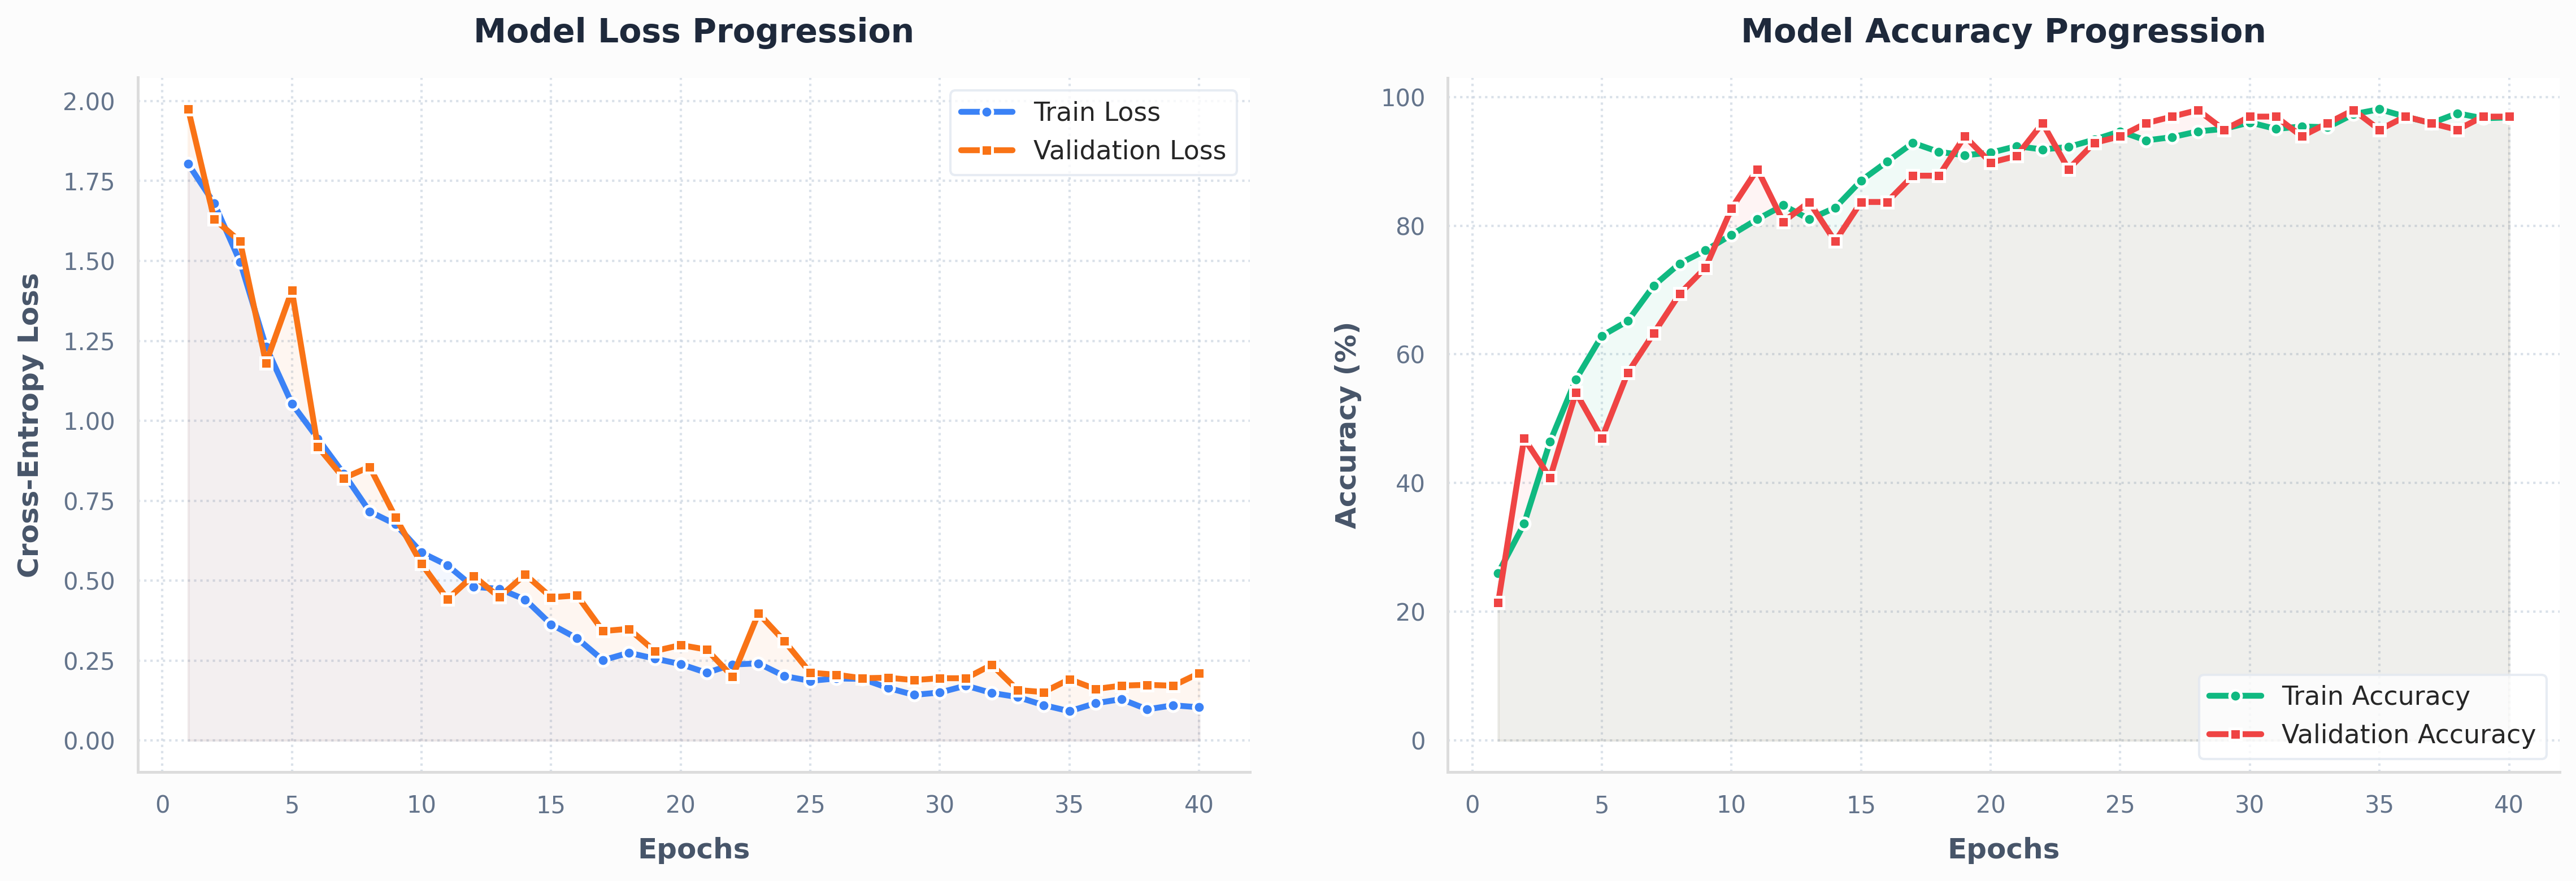

In [22]:

# ============================================================
# Cell: Ultra-Premium Loss and Accuracy Graphs
# ============================================================

# Apply professional styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "axes.edgecolor": "#dcdcdc",
    "axes.linewidth": 1.2,
})

epochs_range = range(1, len(history["train_loss"]) + 1)

# Initialize figure with a modern aspect ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
fig.patch.set_facecolor("#fcfcfc")
ax1.set_facecolor("#ffffff")
ax2.set_facecolor("#ffffff")

# Custom Color Palette (Sophisticated & Clean)
train_color = "#3b82f6"  # Vibrant Modern Blue
val_color = "#f97316"    # Warm Orange/Coral
train_acc_color = "#10b981"  # Emerald Green
val_acc_color = "#ef4444"    # Crimson Red

# ------------------------------------------------------------
# 1. Loss Graph (With Gradient Shading / Confidence-like Band)
# ------------------------------------------------------------
ax1.plot(
    epochs_range, history["train_loss"], 
    label="Train Loss", 
    color=train_color, 
    linewidth=2.5, 
    marker="o", 
    markersize=5, 
    markeredgecolor="#ffffff", 
    markeredgewidth=1.2
)
ax1.plot(
    epochs_range, history["val_loss"], 
    label="Validation Loss", 
    color=val_color, 
    linewidth=2.5, 
    marker="s", 
    markersize=5, 
    markeredgecolor="#ffffff", 
    markeredgewidth=1.2
)

# Soft aesthetic fills under the curves
ax1.fill_between(epochs_range, history["train_loss"], color=train_color, alpha=0.06)
ax1.fill_between(epochs_range, history["val_loss"], color=val_color, alpha=0.06)

ax1.set_title("Model Loss Progression", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
ax1.set_xlabel("Epochs", fontsize=12, fontweight="600", labelpad=8, color="#475569")
ax1.set_ylabel("Cross-Entropy Loss", fontsize=12, fontweight="600", labelpad=8, color="#475569")
ax1.legend(frameon=True, facecolor="#ffffff", edgecolor="#e2e8f0", fontsize=11, loc="upper right")
ax1.grid(True, linestyle=":", alpha=0.7, color="#cbd5e1")
ax1.tick_params(colors="#64748b", labelsize=10)

# ------------------------------------------------------------
# 2. Accuracy Graph (With Gradient Shading)
# ------------------------------------------------------------
train_acc_pct = [acc * 100 for acc in history["train_acc"]]
val_acc_pct = [acc * 100 for acc in history["val_acc"]]

ax2.plot(
    epochs_range, train_acc_pct, 
    label="Train Accuracy", 
    color=train_acc_color, 
    linewidth=2.5, 
    marker="o", 
    markersize=5, 
    markeredgecolor="#ffffff", 
    markeredgewidth=1.2
)
ax2.plot(
    epochs_range, val_acc_pct, 
    label="Validation Accuracy", 
    color=val_acc_color, 
    linewidth=2.5, 
    marker="s", 
    markersize=5, 
    markeredgecolor="#ffffff", 
    markeredgewidth=1.2
)

# Soft aesthetic fills under the curves
ax2.fill_between(epochs_range, train_acc_pct, color=train_acc_color, alpha=0.06)
ax2.fill_between(epochs_range, val_acc_pct, color=val_acc_color, alpha=0.06)

ax2.set_title("Model Accuracy Progression", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
ax2.set_xlabel("Epochs", fontsize=12, fontweight="600", labelpad=8, color="#475569")
ax2.set_ylabel("Accuracy (%)", fontsize=12, fontweight="600", labelpad=8, color="#475569")
ax2.legend(frameon=True, facecolor="#ffffff", edgecolor="#e2e8f0", fontsize=11, loc="lower right")
ax2.grid(True, linestyle=":", alpha=0.7, color="#cbd5e1")
ax2.tick_params(colors="#64748b", labelsize=10)

# ------------------------------------------------------------
# Layout Adjustments & Display
# ------------------------------------------------------------
sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout(pad=3.0)
plt.show()

In [23]:
# ============================================================
# Best Model Path
# ============================================================

MODEL_PATH = "/kaggle/working/best_ckplus_cnn.pth"


# ============================================================
# Load Best Checkpoint
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("=" * 55)
print("BEST CHECKPOINT LOADED")
print("=" * 55)

print(f"Model Path          : {MODEL_PATH}")
print(f"Best Epoch          : {checkpoint['epoch']}")
print(
    f"Best Validation Acc : "
    f"{checkpoint['best_val_acc'] * 100:.2f}%"
)


# ============================================================
# Test Evaluation Function
# ============================================================

def evaluate_test_set(model, loader, device):

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            probs = F.softmax(
                outputs,
                dim=1
            )

            preds = outputs.argmax(
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # --------------------------------------------------------
    # Convert to NumPy
    # --------------------------------------------------------

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        all_labels,
        all_preds
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    # --------------------------------------------------------
    # Multi-class ROC-AUC
    # --------------------------------------------------------

    try:

        roc_auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro"
        )

    except ValueError:

        roc_auc = float("nan")

    # --------------------------------------------------------
    # Return Metrics
    # --------------------------------------------------------

    return {
        "Accuracy": acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1-Score (Macro)": f1,
        "MCC": mcc,
        "Cohen Kappa": kappa,
        "ROC AUC (Macro OvR)": roc_auc
    }


# ============================================================
# Run Evaluation
# ============================================================

test_metrics = evaluate_test_set(
    model,
    test_loader,
    DEVICE
)


# ============================================================
# Format Results
# ============================================================

table_data = [

    [
        "Accuracy",
        f"{test_metrics['Accuracy'] * 100:.2f}%"
    ],

    [
        "Precision (Macro)",
        f"{test_metrics['Precision (Macro)']:.4f}"
    ],

    [
        "Recall (Macro)",
        f"{test_metrics['Recall (Macro)']:.4f}"
    ],

    [
        "F1-Score (Macro)",
        f"{test_metrics['F1-Score (Macro)']:.4f}"
    ],

    [
        "Matthews Corr Coef (MCC)",
        f"{test_metrics['MCC']:.4f}"
    ],

    [
        "Cohen's Kappa",
        f"{test_metrics['Cohen Kappa']:.4f}"
    ],

    [
        "ROC AUC Score (Macro)",
        f"{test_metrics['ROC AUC (Macro OvR)']:.4f}"
    ]
]


# ============================================================
# Display
# ============================================================

print()

print("=" * 55)
print("       TEST SET PERFORMANCE EVALUATION")
print("=" * 55)

print(tabulate(
        table_data,
        headers=["Metric", "Score"],
        tablefmt="fancy_grid"
    )
)

BEST CHECKPOINT LOADED
Model Path          : /kaggle/working/best_ckplus_cnn.pth
Best Epoch          : 28
Best Validation Acc : 97.96%

       TEST SET PERFORMANCE EVALUATION
╒══════════════════════════╤═════════╕
│ Metric                   │ Score   │
╞══════════════════════════╪═════════╡
│ Accuracy                 │ 98.99%  │
├──────────────────────────┼─────────┤
│ Precision (Macro)        │ 0.9796  │
├──────────────────────────┼─────────┤
│ Recall (Macro)           │ 0.9921  │
├──────────────────────────┼─────────┤
│ F1-Score (Macro)         │ 0.9849  │
├──────────────────────────┼─────────┤
│ Matthews Corr Coef (MCC) │ 0.9880  │
├──────────────────────────┼─────────┤
│ Cohen's Kappa            │ 0.9879  │
├──────────────────────────┼─────────┤
│ ROC AUC Score (Macro)    │ 0.9986  │
╘══════════════════════════╧═════════╛


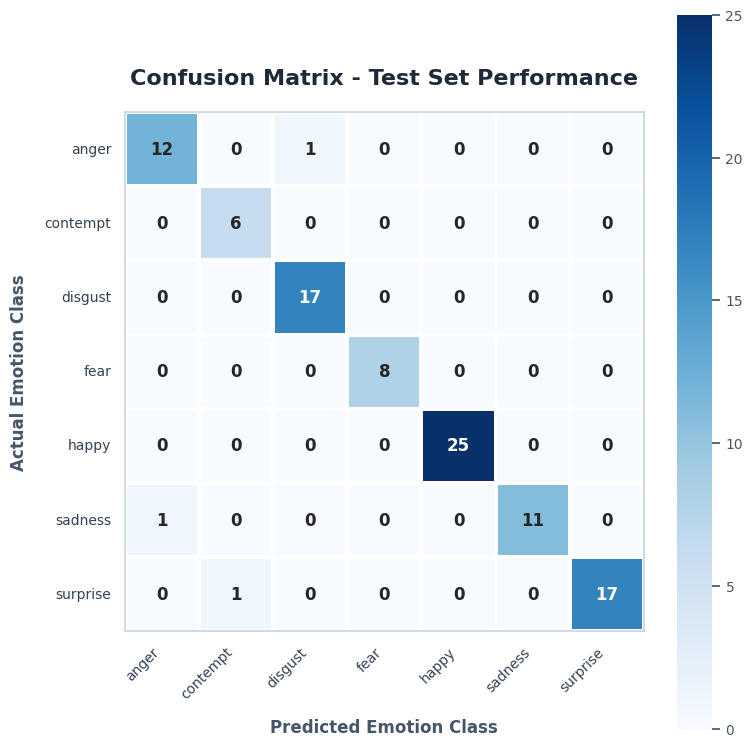

In [24]:

# ============================================================
# Cell: Generate Predictions & Ultra-Premium Confusion Matrix
# ============================================================

model.eval()
all_preds = []
all_labels = []

# Collect predictions from the test loader
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plotting Configuration
plt.figure(figsize=(8, 8))
sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"]
})

# Use class_names if defined in your notebook, otherwise fallback to index numbers
labels_list = class_names if 'class_names' in globals() else [str(i) for i in range(cm.shape[0])]

# Draw the heatmap
ax = sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=True,
    square=True,
    linewidths=1.5,
    linecolor="#ffffff",
    xticklabels=labels_list,
    yticklabels=labels_list,
    annot_kws={"size": 12, "weight": "bold"}
)

# Customize colorbar appearance
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors="#475569")
cbar.outline.set_edgecolor("#cbd5e1")

# Graph Titles & Labels
plt.title("Confusion Matrix - Test Set Performance", fontsize=16, fontweight="bold", pad=20, color="#1e293b")
plt.xlabel("Predicted Emotion Class", fontsize=12, fontweight="600", labelpad=12, color="#475569")
plt.ylabel("Actual Emotion Class", fontsize=12, fontweight="600", labelpad=12, color="#475569")

# Tick configurations
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="500", color="#334155")
plt.yticks(rotation=0, fontsize=10, fontweight="500", color="#334155")

# Aesthetic frame adjustments
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#cbd5e1')

plt.tight_layout()
plt.show()

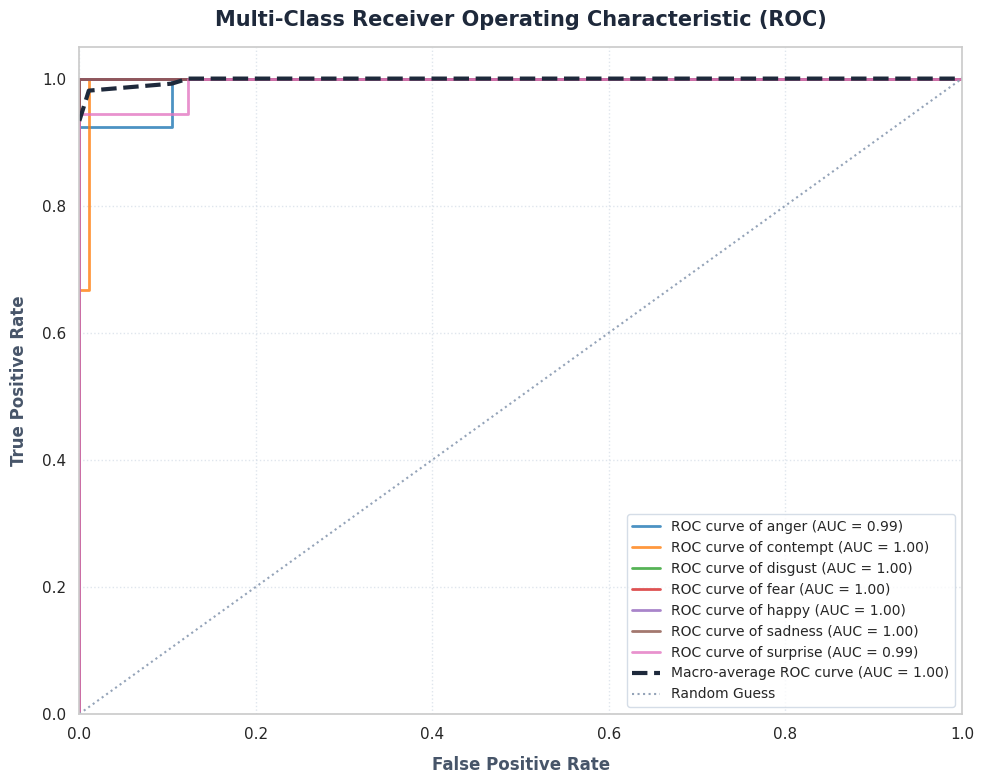

In [25]:
# ============================================================
# Cell: Multi-Class ROC Curves (One-vs-Rest)
# ============================================================

model.eval()
all_labels = []
all_probs = []

# Collect probabilities and true labels from the test loader
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Number of classes
n_classes = all_probs.shape[1]

# Binarize the labels for multi-class ROC curve computation
y_bin = label_binarize(all_labels, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve and ROC area
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ============================================================
# Plotting Configuration
# ============================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"]
})

# Use class_names if available, otherwise generate indices
labels_list = class_names if 'class_names' in globals() else [f"Class {i}" for i in range(n_classes)]

# Color palette for classes
palette = sns.color_palette("tab10", n_classes)

# Plot individual class ROC curves
for i, color in zip(range(n_classes), palette):
    plt.plot(
        fpr[i], tpr[i], 
        color=color, 
        lw=2, 
        alpha=0.8,
        label=f"ROC curve of {labels_list[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Plot macro-average ROC curve
plt.plot(
    fpr["macro"], tpr["macro"],
    color="#1e293b",
    lw=3,
    linestyle="--",
    label=f"Macro-average ROC curve (AUC = {roc_auc['macro']:.2f})"
)

# Plot diagonal reference line (Random Classifier)
plt.plot([0, 1], [0, 1], color="#94a3b8", lw=1.5, linestyle=":", label="Random Guess")

# Graph styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12, fontweight="600", labelpad=10, color="#475569")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="600", labelpad=10, color="#475569")
plt.title("Multi-Class Receiver Operating Characteristic (ROC)", fontsize=15, fontweight="bold", pad=15, color="#1e293b")
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor="#ffffff", edgecolor="#cbd5e1")
plt.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")

plt.tight_layout()
plt.show()

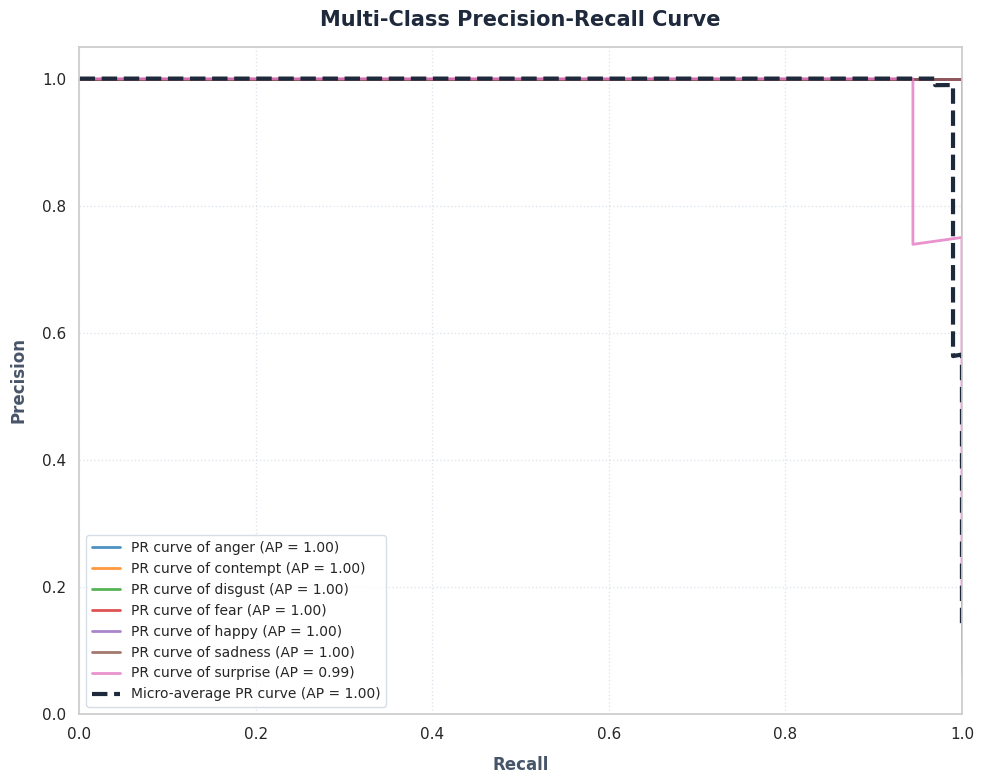

In [26]:

# ============================================================
# Cell: Multi-Class Precision-Recall Curves (One-vs-Rest)
# ============================================================

model.eval()
all_labels = []
all_probs = []

# Collect probabilities and true labels from the test loader
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Number of classes
n_classes = all_probs.shape[1]

# Binarize the labels for multi-class PR curve computation
y_bin = label_binarize(all_labels, classes=range(n_classes))

# Compute Precision-Recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    average_precision[i] = average_precision_score(y_bin[:, i], all_probs[:, i])

# Compute micro-average Precision-Recall curve
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_bin.ravel(), all_probs.ravel()
)
average_precision["micro"] = average_precision_score(y_bin, all_probs, average="micro")

# ============================================================
# Plotting Configuration
# ============================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"]
})

# Use class_names if available, otherwise generate indices
labels_list = class_names if 'class_names' in globals() else [f"Class {i}" for i in range(n_classes)]

# Color palette for classes
palette = sns.color_palette("tab10", n_classes)

# Plot individual class PR curves
for i, color in zip(range(n_classes), palette):
    plt.plot(
        recall[i], precision[i], 
        color=color, 
        lw=2, 
        alpha=0.8,
        label=f"PR curve of {labels_list[i]} (AP = {average_precision[i]:.2f})"
    )

# Plot micro-average PR curve
plt.plot(
    recall["micro"], precision["micro"],
    color="#1e293b",
    lw=3,
    linestyle="--",
    label=f"Micro-average PR curve (AP = {average_precision['micro']:.2f})"
)

# Graph styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall", fontsize=12, fontweight="600", labelpad=10, color="#475569")
plt.ylabel("Precision", fontsize=12, fontweight="600", labelpad=10, color="#475569")
plt.title("Multi-Class Precision-Recall Curve", fontsize=15, fontweight="bold", pad=15, color="#1e293b")
plt.legend(loc="lower left", fontsize=10, frameon=True, facecolor="#ffffff", edgecolor="#cbd5e1")
plt.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")

plt.tight_layout()
plt.show()

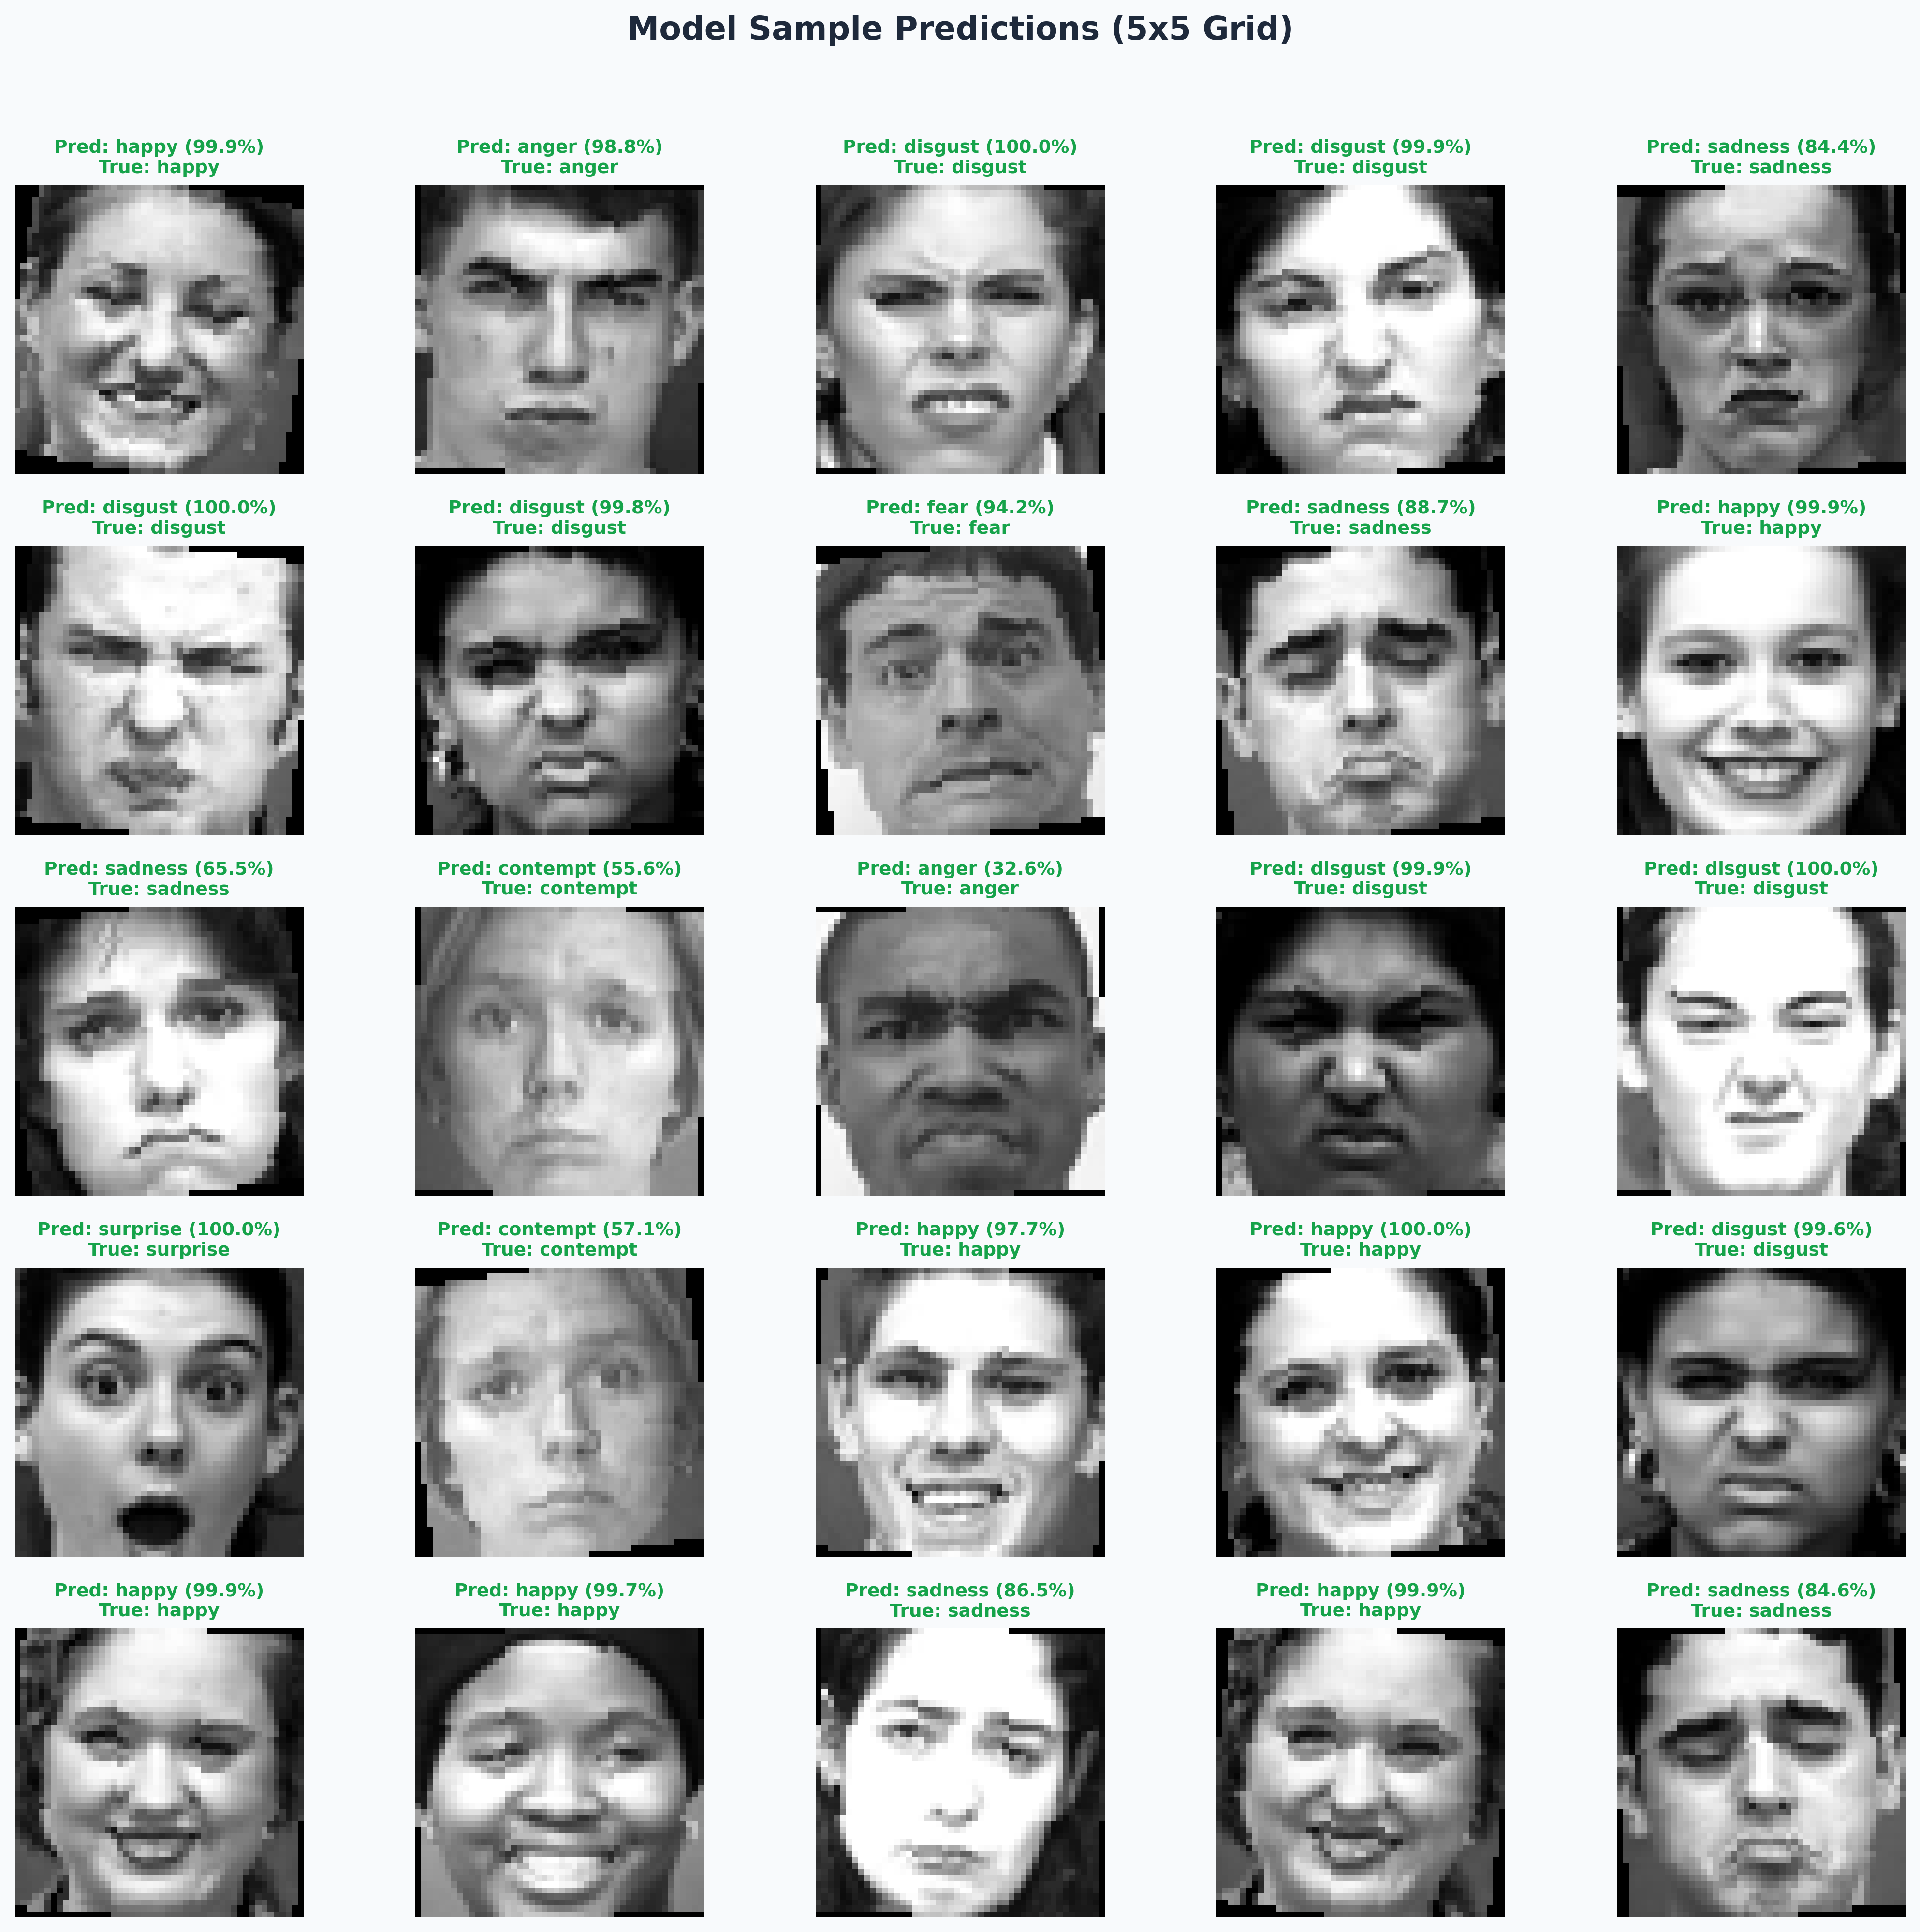

In [27]:
# ============================================================
# Cell: 5x5 Grid Sample Predictions with Color-Coded Titles
# ============================================================

model.eval()

# Retrieve a single batch from the test loader
images, labels = next(iter(test_loader))
images_device = images.to(DEVICE, non_blocking=True)
labels_device = labels.to(DEVICE, non_blocking=True)

with torch.no_grad():
    outputs = model(images_device)
    probs = F.softmax(outputs, dim=1)
    preds = outputs.argmax(dim=1)

# Move data back to CPU for visualization
images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()
probs = probs.cpu()

# Setup 5x5 subplot grid
fig, axes = plt.subplots(5, 5, figsize=(14, 14), dpi=300)
fig.patch.set_facecolor("#f8fafc")

# Use class_names if defined, otherwise fallback to numbers
labels_list = class_names if 'class_names' in globals() else [str(i) for i in range(NUM_CLASSES)]

for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = images[i]
        
        # Handle single-channel (grayscale) or 3-channel images
        if img.shape[0] == 1:
            img = img.squeeze(0)
            ax.imshow(img, cmap="gray")
        else:
            img = img.permute(1, 2, 0)
            ax.imshow(img)
            
        true_label_idx = labels[i].item()
        pred_label_idx = preds[i].item()
        confidence = probs[i][pred_label_idx].item() * 100
        
        true_name = labels_list[true_label_idx]
        pred_name = labels_list[pred_label_idx]
        
        # Green if match, Red if mismatch
        is_match = (true_label_idx == pred_label_idx)
        title_color = "#16a34a" if is_match else "#dc2626"
        
        title_text = f"Pred: {pred_name} ({confidence:.1f}%)\nTrue: {true_name}"
        
        ax.set_title(title_text, fontsize=9, fontweight="bold", color=title_color, pad=6)
        
    ax.axis("off")

plt.suptitle("Model Sample Predictions (5x5 Grid)", fontsize=16, fontweight="bold", y=0.95, color="#1e293b")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Computing t-SNE embeddings (this may take a few seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


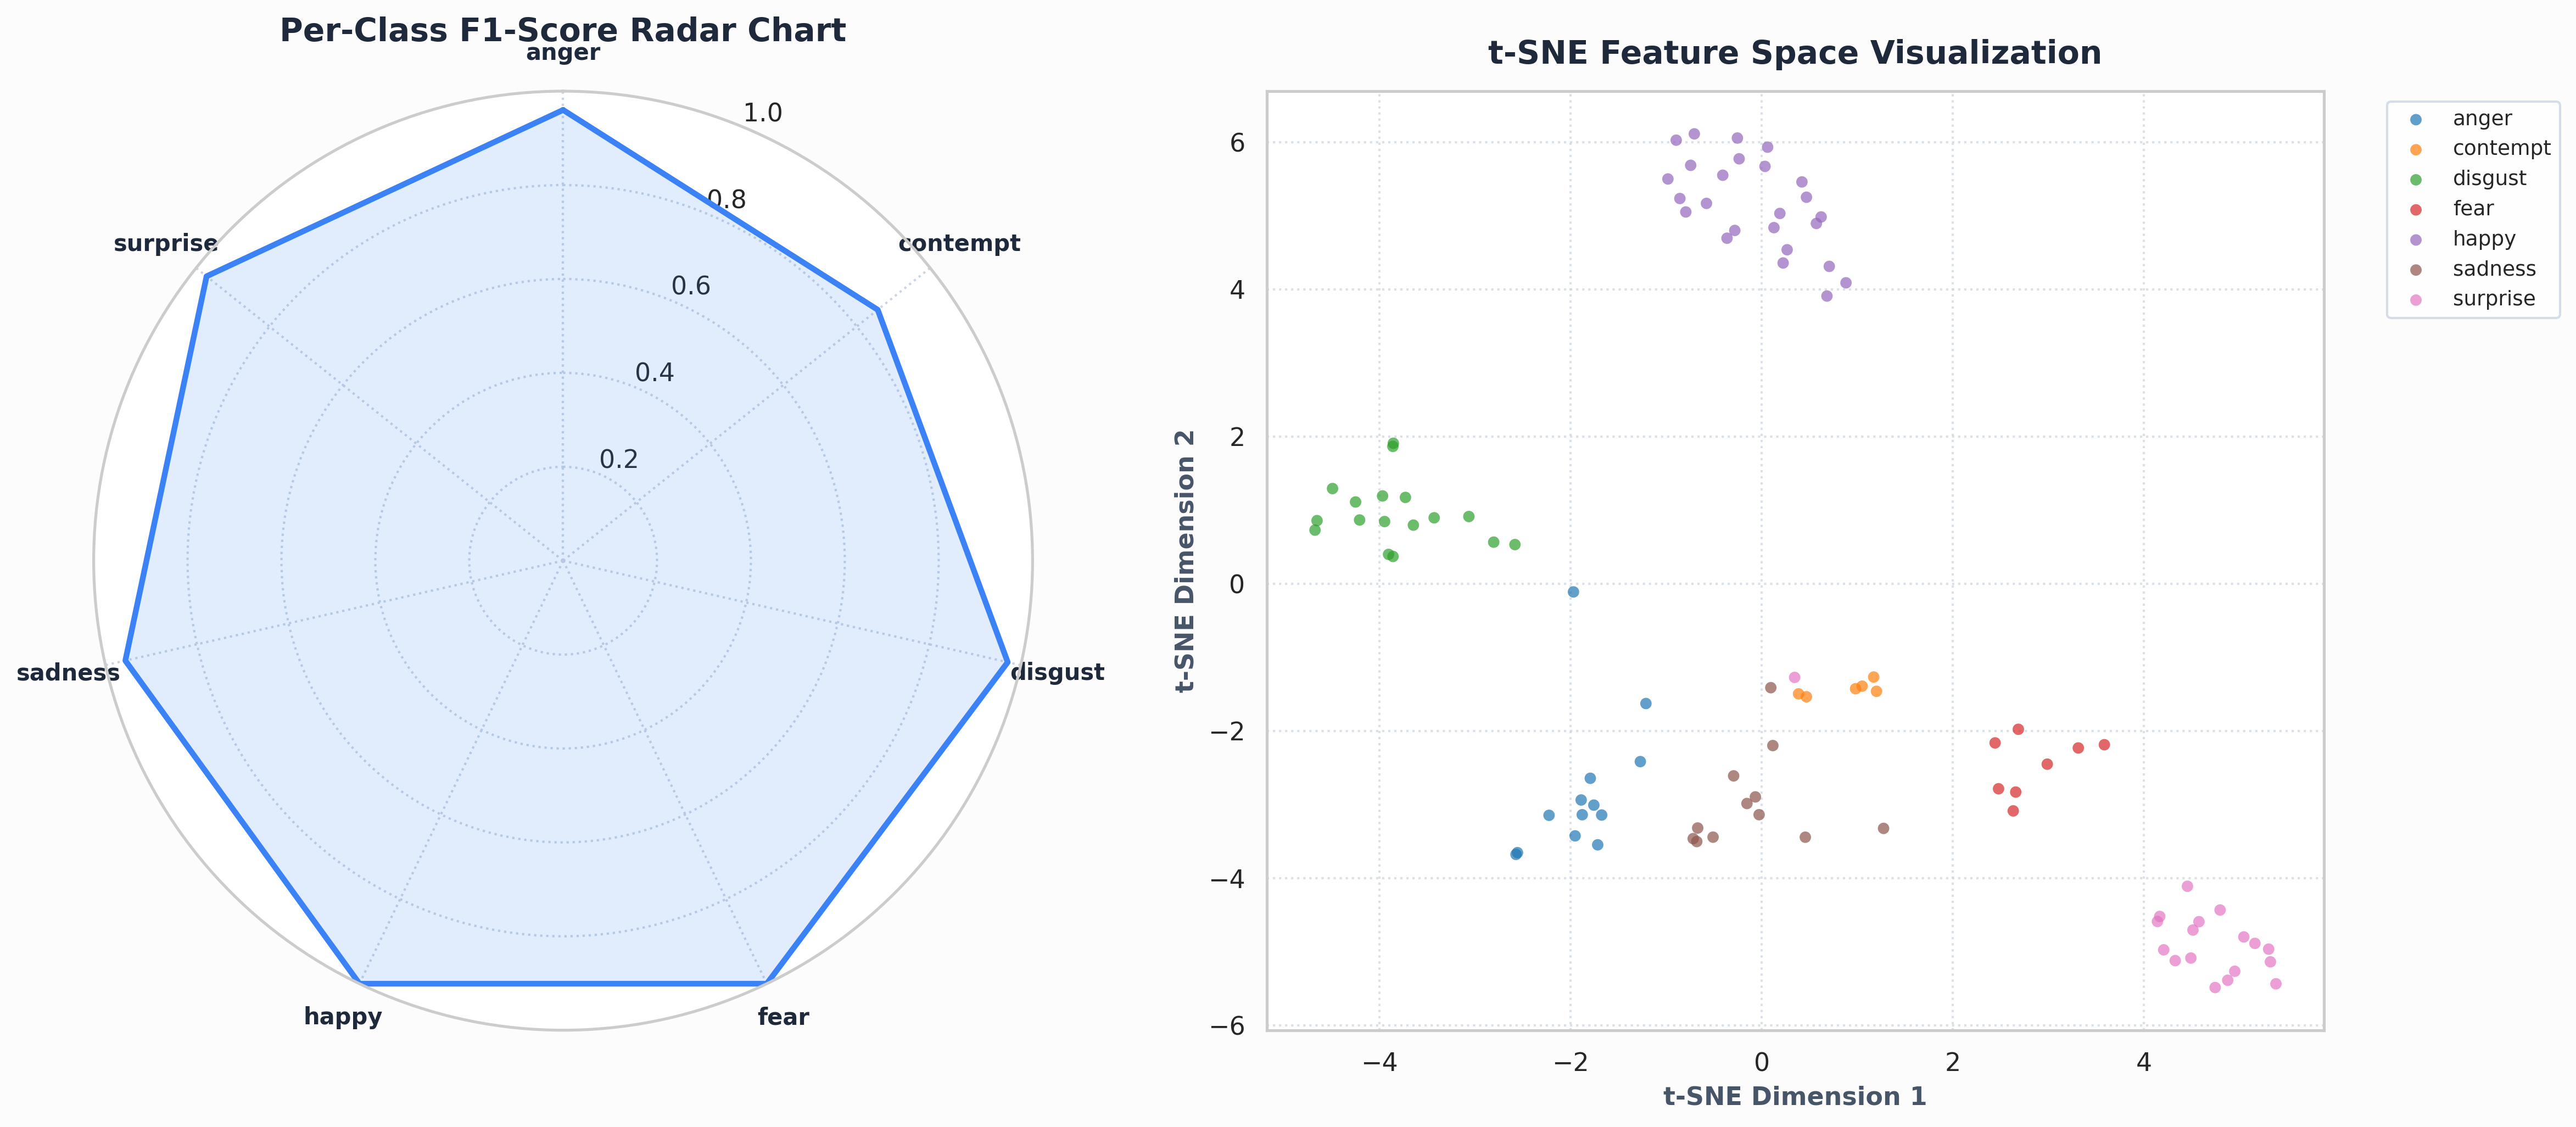

In [28]:
# ============================================================
# Cell: Radar Chart (Per-Class Performance) & t-SNE Embeddings
# ============================================================

model.eval()
all_preds = []
all_labels = []
all_probs = []
embeddings = []

# Hook or forward pass collection to extract features before the classifier layer
# We use the features from the backbone or second-to-last layer if available, 
# or we can extract them via a feature-extracting wrapper hook.
# For simplicity and robustness with Sequential models, we can register a forward hook on the 'features' block.

feature_list = []

def hook_fn(module, input, output):
    # output shape after AdaptiveAvgPool2d is (Batch, 256, 1, 1)
    feature_list.append(output.detach().cpu().numpy())

# Register hook on the last layer of features
handle = model.features[-1].register_forward_hook(hook_fn)

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(DEVICE, non_blocking=True)
        labels_dev = labels.to(DEVICE, non_blocking=True)
        
        outputs = model(images_dev)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

handle.remove()

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
embeddings = np.concatenate(feature_list, axis=0).squeeze() # shape: (N, 256)

labels_list = class_names if 'class_names' in globals() else [f"Class {i}" for i in range(NUM_CLASSES)]
n_classes = len(labels_list)

# ------------------------------------------------------------
# 1. Radar Chart Computation & Plotting
# ------------------------------------------------------------
# Calculate per-class metrics for the radar chart (using Precision, Recall, F1)
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

# We will plot F1-score per class on a radar chart
angles = np.linspace(0, 2 * np.pi, n_classes, endpoint=False).tolist()
angles += angles[:1] # Close the loop

f1_metrics = per_class_f1.tolist()
f1_metrics += f1_metrics[:1]

fig = plt.figure(figsize=(16, 7), dpi=300)
fig.patch.set_facecolor("#fcfcfc")

# Subplot 1: Radar Chart
ax1 = fig.add_subplot(1, 2, 1, polar=True)
ax1.set_facecolor("#ffffff")
ax1.plot(angles, f1_metrics, color="#3b82f6", linewidth=2.5, linestyle="solid", label="F1-Score")
ax1.fill(angles, f1_metrics, color="#3b82f6", alpha=0.15)

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(labels_list, fontsize=10, fontweight="bold", color="#1e293b")
ax1.set_ylim(0, 1.0)
ax1.grid(True, linestyle=":", color="#cbd5e1")
ax1.title.set_text("Per-Class F1-Score Radar Chart\n")
ax1.title.set_fontsize(14)
ax1.title.set_fontweight("bold")
ax1.title.set_color("#1e293b")

# ------------------------------------------------------------
# 2. t-SNE Dimensionality Reduction & Plotting
# ------------------------------------------------------------
print("Computing t-SNE embeddings (this may take a few seconds)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

ax2 = fig.add_subplot(1, 2, 2)
sns.set_theme(style="whitegrid")
palette = sns.color_palette("tab10", n_classes)

for i in range(n_classes):
    idx = np.where(all_labels == i)
    ax2.scatter(
        embeddings_2d[idx, 0], embeddings_2d[idx, 1],
        color=palette[i],
        label=labels_list[i],
        alpha=0.7,
        s=25,
        edgecolors="none"
    )

ax2.set_title("t-SNE Feature Space Visualization", fontsize=14, fontweight="bold", pad=12, color="#1e293b")
ax2.set_xlabel("t-SNE Dimension 1", fontsize=11, fontweight="600", color="#475569")
ax2.set_ylabel("t-SNE Dimension 2", fontsize=11, fontweight="600", color="#475569")
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9, frameon=True, facecolor="#ffffff", edgecolor="#cbd5e1")
ax2.grid(True, linestyle=":", alpha=0.7, color="#cbd5e1")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Cell: Detailed Classification Report
# ============================================================

model.eval()
all_preds = []
all_labels = []

# Collect predictions from the test loader
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Use class_names if defined in your notebook, otherwise fallback to numeric indices
target_names = class_names if 'class_names' in globals() else [str(i) for i in range(NUM_CLASSES)]

# Generate the classification report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=target_names, 
    digits=4, 
    zero_division=0
)

print()
print("=" * 70)
print("             DETAILED CLASSIFICATION REPORT")
print("=" * 70)
print(report)
print("=" * 70)


             DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     1.0000    1.0000    1.0000        13
    contempt     0.8571    1.0000    0.9231         6
     disgust     1.0000    1.0000    1.0000        17
        fear     1.0000    1.0000    1.0000         8
       happy     1.0000    1.0000    1.0000        25
     sadness     1.0000    1.0000    1.0000        12
    surprise     1.0000    0.9444    0.9714        18

    accuracy                         0.9899        99
   macro avg     0.9796    0.9921    0.9849        99
weighted avg     0.9913    0.9899    0.9901        99



In [ ]:

# Cell: Gradio Web Interface for Real-Time Inference
# ============================================================

model.eval()

# Define the image preprocessing pipeline (matching your test/validation transforms)
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure single-channel if model expects grayscale
    transforms.Resize((48, 48)),                 # Match your training input size (IMG_SIZE)
    transforms.ToTensor(),
    # Add normalization here if you used it in your training transforms, e.g.:
    # transforms.Normalize(mean=[0.5], std=[0.5])
])

# Get class labels list
labels_list = class_names if 'class_names' in globals() else [f"Class {i}" for i in range(NUM_CLASSES)]

def predict_emotion(image):
    if image is None:
        return None
    
    # Convert numpy array / PIL image to PIL and preprocess
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype('uint8'), 'RGB')
        
    input_tensor = inference_transform(image).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0].cpu().numpy()
        
    # Map probabilities to class names
    confidences = {labels_list[i]: float(probabilities[i]) for i in range(len(labels_list))}
    return confidences

# Build Gradio UI
demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type="pil", label="Upload or Capture Face Image"),
    outputs=gr.Label(num_top_classes=NUM_CLASSES, label="Predicted Emotion Probabilities"),
    title="CK+48 Facial Expression Recognition",
    description="Upload a facial image or use your webcam to test the custom CNN live.",
    theme="soft"
)

# Launch the app (share=True creates a public link usable in Colab/Kaggle)
demo.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f9c0b4a32d2674ab70.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
